## Importaciones y configuración inicial

In [50]:
# Importaciones generales

# Librerías estándar
import os
import re
import random
import shutil
import unicodedata
from pathlib import Path
from datetime import datetime

# Tratamiento de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Audio
import librosa
from IPython.display import Audio as IPythonAudio, display

# Datasets de Hugging Face
from datasets import load_from_disk, Audio, DatasetDict, Dataset

# Métricas
import evaluate

# PyTorch
import torch

# Transformers / Whisper
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    GenerationConfig,
    set_seed
)

# Utilidades de entrenamiento
from dataclasses import dataclass
from typing import Any, Dict, List, Union

In [25]:
# CONFIGURACIÓN PRINCIPAL

# Nombre del modelo base de Whisper que estamos usando
MODEL_NAME = "openai/whisper-base"

# Ruta del dataset preparado para Whisper
PREPARED_DATASET = r"C:\lara\datasets\lara_whisper_dataset_preparado"

# Ruta del modelo entrenado en el cuaderno 02
INITIAL_MODEL_DIR = r"C:\lara\modelos_entrenados\whisper_base"

# Ruta donde guardaremos el modelo mejorado
IMPROVED_MODEL_DIR = r"C:\lara\modelos_entrenados\whisper_base_mejorado"

# Ruta donde guardaremos resultados, predicciones y análisis de errores
RESULTS_DIR = r"C:\lara\resultados\03_mejora_modelo"

# Archivos de salida para análisis
PREDICTIONS_FILE = r"C:\lara\resultados\03_mejora_modelo\predicciones_modelo_inicial.csv"
ERROR_ANALYSIS_FILE = r"C:\lara\resultados\03_mejora_modelo\analisis_errores_modelo_inicial.csv"

# Ruta donde están los audios convertidos
AUDIOS_CONVERTED_PATH = r"C:\lara\audios-230426\audios-s3"

# Configuración de idioma y tarea
LANGUAGE = "Spanish"
TASK = "transcribe"

# Semilla para intentar que los resultados sean reproducibles
SEED = 42

# Dispositivo de entrenamiento
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Frecuencia de muestreo esperada por Whisper
SAMPLING_RATE = 16000

# Parámetros para generación de predicciones
MAX_NEW_TOKENS = 225
NUM_BEAMS = 1

# Parámetros generales para el nuevo entrenamiento de mejora
NUM_TRAIN_EPOCHS = 10
LEARNING_RATE = 0.000005

TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4

GRADIENT_ACCUMULATION_STEPS = 2  # Batch efectivo = 4 * 2 = 8

# Warmup para estabilizar el entrenamiento
WARMUP_RATIO = 0.1 # Evita que el modelo se descontrole al principio del entrenamiento

# Fijamos la semilla
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Creamos las carpetas necesarias
os.makedirs(IMPROVED_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Configuración cargada correctamente")
print("----------------------------------------")
print("Modelo base:", MODEL_NAME)
print("Dataset preparado:", PREPARED_DATASET)
print("Modelo inicial:", INITIAL_MODEL_DIR)
print("Modelo mejorado:", IMPROVED_MODEL_DIR)
print("Resultados:", RESULTS_DIR)
print("Idioma:", LANGUAGE)
print("Tarea:", TASK)
print("Dispositivo:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Configuración cargada correctamente
----------------------------------------
Modelo base: openai/whisper-base
Dataset preparado: C:\lara\datasets\lara_whisper_dataset_preparado
Modelo inicial: C:\lara\modelos_entrenados\whisper_base
Modelo mejorado: C:\lara\modelos_entrenados\whisper_base_mejorado
Resultados: C:\lara\resultados\03_mejora_modelo
Idioma: Spanish
Tarea: transcribe
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Carga del dataset preparado

In [4]:
# CARGA DEL DATASET PREPARADO

# Cargamos desde disco el dataset preparado para Whisper
dataset = load_from_disk(PREPARED_DATASET)

print("Dataset cargado correctamente")
print("----------------------------------------")
print(dataset)
print("----------------------------------------")

# Mostramos información básica del dataset
print("Número de registros:", len(dataset))
print("Columnas:", dataset.column_names)
print("Features:", dataset.features)
print("----------------------------------------")

# Mostramos un ejemplo para comprobar la estructura
print("Ejemplo del primer registro")
print("----------------------------------------")
print("Columnas disponibles:", dataset[0].keys())
print("Tamaño de input_features:", np.array(dataset[0]["input_features"]).shape)
print("Tamaño de labels:", len(dataset[0]["labels"]))

Loading dataset from disk:   0%|          | 0/79 [00:00<?, ?it/s]

Dataset cargado correctamente
----------------------------------------
Dataset({
    features: ['input_features', 'labels'],
    num_rows: 40842
})
----------------------------------------
Número de registros: 40842
Columnas: ['input_features', 'labels']
Features: {'input_features': Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}
----------------------------------------
Ejemplo del primer registro
----------------------------------------
Columnas disponibles: dict_keys(['input_features', 'labels'])
Tamaño de input_features: (80, 3000)
Tamaño de labels: 14


In [5]:
# DIVISIÓN DEL DATASET EN TRAIN / TEST / VALIDATION

# Primera división:
# 80% para entrenamiento y 20% para separar después entre test y validación
dataset_split = dataset.train_test_split(
    test_size=0.2,
    seed=SEED,
    shuffle=True
)

# Segunda división:
# Del 20% restante, dejamos el 80% para test y el 20% para validación
test_validation_split = dataset_split["test"].train_test_split(
    test_size=0.2,
    seed=SEED,
    shuffle=True
)

# Creamos el diccionario final de particiones
dataset_splits = DatasetDict({
    "train": dataset_split["train"],
    "test": test_validation_split["train"],
    "validation": test_validation_split["test"]
})

print("Dataset dividido correctamente")
print("----------------------------------------")
print("Train:", len(dataset_splits["train"]))
print("Test:", len(dataset_splits["test"]))
print("Validation:", len(dataset_splits["validation"]))
print("----------------------------------------")
print(dataset_splits)

Dataset dividido correctamente
----------------------------------------
Train: 32673
Test: 6535
Validation: 1634
----------------------------------------
DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 32673
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 6535
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1634
    })
})


## Carga del processor, del modelo inicial y las métricas

In [6]:
# CARGA DEL PROCESSOR, MODELO INICIAL Y MÉTRICAS

# Cargamos el processor desde el modelo base original
# El processor contiene el tokenizer y el feature extractor de Whisper
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language=LANGUAGE,
    task=TASK
)

# Cargamos el modelo entrenado en el cuaderno 02
model = WhisperForConditionalGeneration.from_pretrained(INITIAL_MODEL_DIR)

# Movemos el modelo a GPU si está disponible
model.to(DEVICE)

# Configuramos idioma y tarea para la generación de texto
model.generation_config.language = LANGUAGE
model.generation_config.task = TASK
model.generation_config.forced_decoder_ids = None

# Cargamos las métricas que usaremos para evaluar
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

print("Processor, modelo inicial y métricas cargados correctamente")
print("----------------------------------------")
print("Modelo inicial:", INITIAL_MODEL_DIR)
print("Dispositivo:", DEVICE)
print("Métricas cargadas: WER y CER")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Processor, modelo inicial y métricas cargados correctamente
----------------------------------------
Modelo inicial: C:\lara\modelos_entrenados\whisper_base
Dispositivo: cuda
Métricas cargadas: WER y CER


## Data collator

In [7]:
# DATA COLLATOR PARA WHISPER

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:

        # Preparamos las características de audio
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        # Preparamos las etiquetas de texto
        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        # Sustituimos el padding por -100 para que no compute en la loss
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        # Eliminamos el token inicial si ya está añadido en todas las etiquetas
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

print("Data collator creado correctamente")

Data collator creado correctamente


## Métricas WER y CER

In [8]:
# FUNCIÓN PARA CALCULAR MÉTRICAS WER Y CER

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Sustituimos -100 por el token de padding para poder decodificar las etiquetas
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decodificamos predicciones y etiquetas
    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    # Calculamos métricas principales
    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer
    }


print("Función de métricas creada correctamente")

Función de métricas creada correctamente


## Evaluación del modelo inicial

In [9]:
# CONFIGURACIÓN DEL TRAINER PARA EVALUAR EL MODELO INICIAL

training_args_eval = Seq2SeqTrainingArguments(
    output_dir=RESULTS_DIR,

    # En esta fase solo queremos evaluar, no entrenar
    do_train=False,
    do_eval=True,

    # Tamaño de batch para evaluación
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    # Necesario para que Whisper genere texto y podamos calcular WER/CER
    predict_with_generate=True,
    generation_max_length=MAX_NEW_TOKENS,
    generation_num_beams=NUM_BEAMS,         # Usamos 1 beam para que sea más rápido, aunque podríamos probar con más para mejorar resultados

    # Precisión mixta si usamos GPU
    fp16=torch.cuda.is_available(),

    # Evitamos logs innecesarios
    report_to=[],
    logging_strategy="no",

    # No necesitamos guardar checkpoints en esta evaluación
    save_strategy="no"
)

trainer_eval_inicial = Seq2SeqTrainer(
    args=training_args_eval,
    model=model,
    eval_dataset=dataset_splits["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor
)

print("Trainer de evaluación creado correctamente")
print("----------------------------------------")
print("Registros de test:", len(dataset_splits["test"]))
print("Batch de evaluación:", EVAL_BATCH_SIZE)
print("Generación máxima de tokens:", MAX_NEW_TOKENS)
print("Número de beams:", NUM_BEAMS)

Trainer de evaluación creado correctamente
----------------------------------------
Registros de test: 6535
Batch de evaluación: 4
Generación máxima de tokens: 225
Número de beams: 1


In [10]:
resultados_test_inicial = trainer_eval_inicial.evaluate()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Training Loss,Validation Loss,Step,Wer,Cer
No log,0.132329,0,0.575575,0.425761


In [12]:
# COMPROBAMOS LAS CLAVES DISPONIBLES EN LOS RESULTADOS

print("Claves disponibles en resultados_test_inicial:")
print("----------------------------------------")

for clave, valor in resultados_test_inicial.items():
    print(clave, ":", valor)

Claves disponibles en resultados_test_inicial:
----------------------------------------
eval_loss : 0.13232871890068054
eval_wer : 0.5755753732663011
eval_cer : 0.4257612707932019


In [13]:
# GUARDADO DE RESULTADOS DEL MODELO INICIAL

# Guardamos los resultados de evaluación en un diccionario más limpio
# Usamos .get() para evitar errores si alguna métrica auxiliar no está disponible
metricas_modelo_inicial = {
    "modelo": "whisper_base_inicial",
    "loss": resultados_test_inicial.get("eval_loss"),
    "wer": resultados_test_inicial.get("eval_wer"),
    "cer": resultados_test_inicial.get("eval_cer"),
    "runtime": resultados_test_inicial.get("eval_runtime"),
    "samples_per_second": resultados_test_inicial.get("eval_samples_per_second"),
    "steps_per_second": resultados_test_inicial.get("eval_steps_per_second"),
    "fecha_evaluacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Convertimos a DataFrame para verlo y poder guardarlo fácilmente
df_metricas_inicial = pd.DataFrame([metricas_modelo_inicial])

# Ruta del archivo de métricas
METRICS_INITIAL_FILE = os.path.join(RESULTS_DIR, "metricas_modelo_inicial.csv")

# Guardamos el CSV
df_metricas_inicial.to_csv(
    METRICS_INITIAL_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Métricas del modelo inicial guardadas correctamente")
print("----------------------------------------")
print(df_metricas_inicial)
print("----------------------------------------")
print("Archivo guardado en:", METRICS_INITIAL_FILE)

Métricas del modelo inicial guardadas correctamente
----------------------------------------
                 modelo      loss       wer       cer runtime  \
0  whisper_base_inicial  0.132329  0.575575  0.425761    None   

  samples_per_second steps_per_second     fecha_evaluacion  
0               None             None  2026-05-16 22:35:43  
----------------------------------------
Archivo guardado en: C:\lara\resultados\03_mejora_modelo\metricas_modelo_inicial.csv


In [14]:
# GENERACIÓN DE PREDICCIONES DEL MODELO INICIAL SOBRE TEST

# Generamos predicciones usando el trainer de evaluación
predicciones_test_inicial = trainer_eval_inicial.predict(
    dataset_splits["test"]
)

# Extraemos predicciones y etiquetas reales
pred_ids = predicciones_test_inicial.predictions
label_ids = predicciones_test_inicial.label_ids

# Sustituimos -100 por el token de padding para poder decodificar las etiquetas
label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

# Decodificamos predicciones y textos reales
textos_predichos = processor.tokenizer.batch_decode(
    pred_ids,
    skip_special_tokens=True
)

textos_reales = processor.tokenizer.batch_decode(
    label_ids,
    skip_special_tokens=True
)

# Creamos una tabla base con resultados por registro
df_predicciones_inicial = pd.DataFrame({
    "indice_test": range(len(textos_reales)),
    "texto_real": textos_reales,
    "texto_predicho": textos_predichos
})

# Guardamos las predicciones en CSV
df_predicciones_inicial.to_csv(
    PREDICTIONS_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Predicciones generadas correctamente")
print("----------------------------------------")
print("Número de predicciones:", len(df_predicciones_inicial))
print("Archivo guardado en:", PREDICTIONS_FILE)
print("----------------------------------------")
display(df_predicciones_inicial.head(10))

Predicciones generadas correctamente
----------------------------------------
Número de predicciones: 6535
Archivo guardado en: C:\lara\resultados\03_mejora_modelo\predicciones_modelo_inicial.csv
----------------------------------------


,indice_test,texto_real,texto_predicho
0,0,EN LA LATA HAY LIMONADA.,EN LA LATA HAY LIMONADA.
1,1,ME ASOMARÉ DESDE EL DÉCIMO PISO.,ME ASOMARÉ DESDE EL DÉCIMO PISO.
2,2,AFRONTAR LA AFRENTA DE ALFREDO.,AFRONTAR LA AFRENTA DE ALFREDO.
3,3,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...
4,4,EL CIELO ES CALIDO,EL GRIEGO DE PELO GRIS TIENE GRIPA.
5,5,MAÑANA IRÉ AL PALMERAL.,A NADAR TIENE UNA GRAN PANADERA.
6,6,LA IGUANA COME INSECTOS,EL IGNOR NO COME INSECTOS
7,7,EL NOVIO SUBIÓ A LA NOVIA.,EL NOVIO SUBIÓ A LA NOVIA.
8,8,EL AZÚCAR ES BLANCO.,EL AZÚCAR ES BLANCO.
9,9,"¡JODER JUAN, QUÉ HEAVY!",¡CORRO! QUE JEFE


In [15]:
# CÁLCULO DE WER Y CER POR CADA PREDICCIÓN

# Calculamos WER y CER individualmente para cada fila
wer_por_fila = []
cer_por_fila = []

for texto_real, texto_predicho in zip(
    df_predicciones_inicial["texto_real"],
    df_predicciones_inicial["texto_predicho"]
):
    wer_fila = wer_metric.compute(
        predictions=[texto_predicho],
        references=[texto_real]
    )

    cer_fila = cer_metric.compute(
        predictions=[texto_predicho],
        references=[texto_real]
    )

    wer_por_fila.append(wer_fila)
    cer_por_fila.append(cer_fila)

# Añadimos las métricas al DataFrame
df_predicciones_inicial["wer"] = wer_por_fila
df_predicciones_inicial["cer"] = cer_por_fila

# Ordenamos por WER y CER para localizar los peores casos
df_errores_inicial = df_predicciones_inicial.sort_values(
    by=["wer", "cer"],
    ascending=False
).reset_index(drop=True)

# Guardamos el análisis de errores
df_errores_inicial.to_csv(
    ERROR_ANALYSIS_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Análisis de errores generado correctamente")
print("----------------------------------------")
print("WER medio:", df_predicciones_inicial["wer"].mean())
print("CER medio:", df_predicciones_inicial["cer"].mean())
print("Archivo guardado en:", ERROR_ANALYSIS_FILE)
print("----------------------------------------")

display(df_errores_inicial.head(20))

Análisis de errores generado correctamente
----------------------------------------
WER medio: 0.5873307797084977
CER medio: 0.42534135352205343
Archivo guardado en: C:\lara\resultados\03_mejora_modelo\analisis_errores_modelo_inicial.csv
----------------------------------------


,indice_test,texto_real,texto_predicho,wer,cer
0,3370,SE AGRADECE TU ALEGRÍA.,TEA LA TELENO QUE PESA PESA PESA PESA PESA PE...,18.750000,15.652174
1,6501,AL RECIBIR EL DIPLOMA LE DIERON MUCHOS APLAUSOS.,ESTUVE EN LA CIMA DE CIMA PORQUE NO LLEVÓ EL C...,13.625000,9.395833
2,270,AL CRUZAR EL PUENTE ME CRUJIERON LOS HUESOS DE...,LA FUENTE DE LA FUENTE ME COMPRA LA FUENTE DE ...,13.100000,9.763636
3,4544,JUGAMOS AL PARCHÍS CON FICHAS.,¡JUANJO ES EL JEFE CORTANDO SALTANDO PORTANDO ...,11.400000,14.266667
4,2086,MI HIJA ES UNA GRAN FANÁTICA DE LOS POSTRES Y ...,ME ENCANTA IR AL PARQUE T T T T T T T T T T T ...,9.434783,3.385246
5,4926,RECLAMAN CICLOS FORMATIVOS DE RECICLAJE.,LOS MÁS TREPITAN TREPITAN TREPITAN TREPITAN TR...,9.200000,9.400000
6,2001,Hola,EL HAZ DE LUZ ASUSTÓ AL RAPAZ.,7.000000,7.250000
7,126,MI ABUELA SIEMPRE ME ENSEÑA A PREPARAR PLATOS ...,IREMOS A LA PANTERA EN LA PANTERA EN LA PANTER...,5.000000,5.012658
8,5600,COLOCAME,¡CORRO! QUE CANCIÓN MÁS COCHINA,5.000000,3.125000
9,2389,COLOCAME,¡CORRO HE IDO AL CORREO!,5.000000,2.375000


In [16]:
# RESUMEN ESTADÍSTICO DE ERRORES DEL MODELO INICIAL

print("Resumen estadístico de errores")
print("----------------------------------------")

print("WER")
print(df_predicciones_inicial["wer"].describe())
print("----------------------------------------")

print("CER")
print(df_predicciones_inicial["cer"].describe())
print("----------------------------------------")

# Contamos cuántos registros superan ciertos umbrales de error
umbrales = [0, 0.25, 0.5, 0.75, 1, 2, 5]

print("Registros por umbral de WER")
print("----------------------------------------")

for umbral in umbrales:
    cantidad = (df_predicciones_inicial["wer"] > umbral).sum()
    porcentaje = cantidad / len(df_predicciones_inicial) * 100
    print(f"WER > {umbral}: {cantidad} registros ({porcentaje:.2f}%)")

print("----------------------------------------")
print("Registros por umbral de CER")
print("----------------------------------------")

for umbral in umbrales:
    cantidad = (df_predicciones_inicial["cer"] > umbral).sum()
    porcentaje = cantidad / len(df_predicciones_inicial) * 100
    print(f"CER > {umbral}: {cantidad} registros ({porcentaje:.2f}%)")

Resumen estadístico de errores
----------------------------------------
WER
count    6535.000000
mean        0.587331
std         0.736219
min         0.000000
25%         0.000000
50%         0.400000
75%         1.000000
max        18.750000
Name: wer, dtype: float64
----------------------------------------
CER
count    6535.000000
mean        0.425341
std         0.644377
min         0.000000
25%         0.000000
50%         0.241379
75%         0.757576
max        16.000000
Name: cer, dtype: float64
----------------------------------------
Registros por umbral de WER
----------------------------------------
WER > 0: 3805 registros (58.22%)
WER > 0.25: 3405 registros (52.10%)
WER > 0.5: 3092 registros (47.31%)
WER > 0.75: 2742 registros (41.96%)
WER > 1: 1317 registros (20.15%)
WER > 2: 110 registros (1.68%)
WER > 5: 7 registros (0.11%)
----------------------------------------
Registros por umbral de CER
----------------------------------------
CER > 0: 3805 registros (58.22%)
CER >

In [17]:
# ANÁLISIS DE LONGITUD DE TEXTOS REALES Y PREDICHOS

# Calculamos número de palabras y caracteres del texto real y del texto predicho
df_predicciones_inicial["palabras_real"] = df_predicciones_inicial["texto_real"].apply(
    lambda x: len(str(x).split())
)

df_predicciones_inicial["palabras_predicho"] = df_predicciones_inicial["texto_predicho"].apply(
    lambda x: len(str(x).split())
)

df_predicciones_inicial["caracteres_real"] = df_predicciones_inicial["texto_real"].apply(
    lambda x: len(str(x))
)

df_predicciones_inicial["caracteres_predicho"] = df_predicciones_inicial["texto_predicho"].apply(
    lambda x: len(str(x))
)

# Calculamos diferencias de longitud entre predicción y texto real
df_predicciones_inicial["diferencia_palabras"] = (
    df_predicciones_inicial["palabras_predicho"] - df_predicciones_inicial["palabras_real"]
)

df_predicciones_inicial["diferencia_caracteres"] = (
    df_predicciones_inicial["caracteres_predicho"] - df_predicciones_inicial["caracteres_real"]
)

# Calculamos también la diferencia absoluta
df_predicciones_inicial["diferencia_abs_palabras"] = df_predicciones_inicial["diferencia_palabras"].abs()
df_predicciones_inicial["diferencia_abs_caracteres"] = df_predicciones_inicial["diferencia_caracteres"].abs()

print("Columnas de longitud añadidas correctamente")
print("----------------------------------------")

print("Resumen de palabras reales")
print(df_predicciones_inicial["palabras_real"].describe())
print("----------------------------------------")

print("Resumen de palabras predichas")
print(df_predicciones_inicial["palabras_predicho"].describe())
print("----------------------------------------")

print("Resumen de diferencia de palabras")
print(df_predicciones_inicial["diferencia_palabras"].describe())
print("----------------------------------------")

# Mostramos los casos donde el modelo genera mucho más texto del esperado
df_predicciones_largas = df_predicciones_inicial.sort_values(
    by="diferencia_palabras",
    ascending=False
).reset_index(drop=True)

print("Casos donde el modelo genera más palabras que el texto real")
print("----------------------------------------")
display(
    df_predicciones_largas[
        [
            "indice_test",
            "texto_real",
            "texto_predicho",
            "palabras_real",
            "palabras_predicho",
            "diferencia_palabras",
            "wer",
            "cer"
        ]
    ].head(20)
)

Columnas de longitud añadidas correctamente
----------------------------------------
Resumen de palabras reales
count    6535.000000
mean        6.057077
std         1.998381
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        24.000000
Name: palabras_real, dtype: float64
----------------------------------------
Resumen de palabras predichas
count    6535.00000
mean        6.65065
std         4.18232
min         2.00000
25%         5.00000
50%         6.00000
75%         8.00000
max       217.00000
Name: palabras_predicho, dtype: float64
----------------------------------------
Resumen de diferencia de palabras
count    6535.000000
mean        0.593573
std         3.769298
min       -14.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       194.000000
Name: diferencia_palabras, dtype: float64
----------------------------------------
Casos donde el modelo genera más palabras que el texto real
---------------------------

,indice_test,texto_real,texto_predicho,palabras_real,palabras_predicho,diferencia_palabras,wer,cer
0,2086,MI HIJA ES UNA GRAN FANÁTICA DE LOS POSTRES Y ...,ME ENCANTA IR AL PARQUE T T T T T T T T T T T ...,23,217,194,9.434783,3.385246
1,270,AL CRUZAR EL PUENTE ME CRUJIERON LOS HUESOS DE...,LA FUENTE DE LA FUENTE ME COMPRA LA FUENTE DE ...,10,132,122,13.100000,9.763636
2,6501,AL RECIBIR EL DIPLOMA LE DIERON MUCHOS APLAUSOS.,ESTUVE EN LA CIMA DE CIMA PORQUE NO LLEVÓ EL C...,8,110,102,13.625000,9.395833
3,3370,SE AGRADECE TU ALEGRÍA.,TEA LA TELENO QUE PESA PESA PESA PESA PESA PE...,4,75,71,18.750000,15.652174
4,4544,JUGAMOS AL PARCHÍS CON FICHAS.,¡JUANJO ES EL JEFE CORTANDO SALTANDO PORTANDO ...,5,57,52,11.400000,14.266667
5,126,MI ABUELA SIEMPRE ME ENSEÑA A PREPARAR PLATOS ...,IREMOS A LA PANTERA EN LA PANTERA EN LA PANTER...,12,60,48,5.000000,5.012658
6,4926,RECLAMAN CICLOS FORMATIVOS DE RECICLAJE.,LOS MÁS TREPITAN TREPITAN TREPITAN TREPITAN TR...,5,46,41,9.200000,9.400000
7,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",4,16,12,3.750000,5.000000
8,5998,COMÍ CODILLO CON BELLOTAS.,ES UN AMBIENTE CONFLICTIVO DE MIS AMIGOS Y LEJ...,4,16,12,4.000000,2.653846
9,1342,LA TABLA DE TANTA CERA QUE RESBALA,LA TABLA DE TANTA CERA QUE EL MAR VI A LA TIEN...,7,19,12,1.857143,1.500000


In [18]:
# ANÁLISIS DE SOBRERGENERACIÓN DEL MODELO INICIAL

# Consideramos sobregeneración cuando el modelo genera muchas más palabras que el texto real
umbrales_sobregeneracion = [5, 10, 20, 50, 100]

print("Análisis de sobregeneración")
print("----------------------------------------")

for umbral in umbrales_sobregeneracion:
    cantidad = (df_predicciones_inicial["diferencia_palabras"] > umbral).sum()
    porcentaje = cantidad / len(df_predicciones_inicial) * 100
    print(f"Diferencia de palabras > {umbral}: {cantidad} registros ({porcentaje:.2f}%)")

print("----------------------------------------")

# Casos donde el modelo genera bastante más texto del esperado
df_sobregeneracion = df_predicciones_inicial[
    df_predicciones_inicial["diferencia_palabras"] > 10
].sort_values(
    by="diferencia_palabras",
    ascending=False
).reset_index(drop=True)

print("Registros con diferencia de palabras > 10:", len(df_sobregeneracion))
print("----------------------------------------")

display(
    df_sobregeneracion[
        [
            "indice_test",
            "texto_real",
            "texto_predicho",
            "palabras_real",
            "palabras_predicho",
            "diferencia_palabras",
            "wer",
            "cer"
        ]
    ].head(30)
)

Análisis de sobregeneración
----------------------------------------
Diferencia de palabras > 5: 103 registros (1.58%)
Diferencia de palabras > 10: 12 registros (0.18%)
Diferencia de palabras > 20: 7 registros (0.11%)
Diferencia de palabras > 50: 5 registros (0.08%)
Diferencia de palabras > 100: 3 registros (0.05%)
----------------------------------------
Registros con diferencia de palabras > 10: 12
----------------------------------------


,indice_test,texto_real,texto_predicho,palabras_real,palabras_predicho,diferencia_palabras,wer,cer
0,2086,MI HIJA ES UNA GRAN FANÁTICA DE LOS POSTRES Y ...,ME ENCANTA IR AL PARQUE T T T T T T T T T T T ...,23,217,194,9.434783,3.385246
1,270,AL CRUZAR EL PUENTE ME CRUJIERON LOS HUESOS DE...,LA FUENTE DE LA FUENTE ME COMPRA LA FUENTE DE ...,10,132,122,13.100000,9.763636
2,6501,AL RECIBIR EL DIPLOMA LE DIERON MUCHOS APLAUSOS.,ESTUVE EN LA CIMA DE CIMA PORQUE NO LLEVÓ EL C...,8,110,102,13.625000,9.395833
3,3370,SE AGRADECE TU ALEGRÍA.,TEA LA TELENO QUE PESA PESA PESA PESA PESA PE...,4,75,71,18.750000,15.652174
4,4544,JUGAMOS AL PARCHÍS CON FICHAS.,¡JUANJO ES EL JEFE CORTANDO SALTANDO PORTANDO ...,5,57,52,11.400000,14.266667
5,126,MI ABUELA SIEMPRE ME ENSEÑA A PREPARAR PLATOS ...,IREMOS A LA PANTERA EN LA PANTERA EN LA PANTER...,12,60,48,5.000000,5.012658
6,4926,RECLAMAN CICLOS FORMATIVOS DE RECICLAJE.,LOS MÁS TREPITAN TREPITAN TREPITAN TREPITAN TR...,5,46,41,9.200000,9.400000
7,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",4,16,12,3.750000,5.000000
8,1342,LA TABLA DE TANTA CERA QUE RESBALA,LA TABLA DE TANTA CERA QUE EL MAR VI A LA TIEN...,7,19,12,1.857143,1.500000
9,2195,ME HIZO FLIPAR.,HOY NO ME PUEDO LEVANTAR PORQUE EN LA NOVIA EN...,3,15,12,4.666667,4.133333


#### Conclusión

1. El modelo funciona razonablemente en muchas frases cortas.
2. Una parte de los errores viene de predicciones completamente desviadas.
3. Los casos de alucinación larga existen, pero son minoritarios.
4. La mayor parte del error probablemente viene de predicciones incorrectas de longitud parecida al texto real.

In [19]:
# ANÁLISIS DE ERRORES SEGÚN LONGITUD DEL TEXTO REAL

# Creamos grupos según número de palabras reales
def clasificar_longitud_texto(num_palabras):
    if num_palabras <= 3:
        return "1-3 palabras"
    elif num_palabras <= 7:
        return "4-7 palabras"
    elif num_palabras <= 12:
        return "8-12 palabras"
    else:
        return "13+ palabras"


df_predicciones_inicial["grupo_longitud_real"] = df_predicciones_inicial["palabras_real"].apply(
    clasificar_longitud_texto
)

# Calculamos estadísticas por grupo
df_errores_por_longitud = (
    df_predicciones_inicial
    .groupby("grupo_longitud_real")
    .agg(
        registros=("indice_test", "count"),
        wer_medio=("wer", "mean"),
        cer_medio=("cer", "mean"),
        wer_mediana=("wer", "median"),
        cer_mediana=("cer", "median"),
        palabras_real_media=("palabras_real", "mean"),
        palabras_predichas_media=("palabras_predicho", "mean")
    )
    .reset_index()
)

# Ordenamos los grupos manualmente
orden_grupos = {
    "1-3 palabras": 1,
    "4-7 palabras": 2,
    "8-12 palabras": 3,
    "13+ palabras": 4
}

df_errores_por_longitud["orden"] = df_errores_por_longitud["grupo_longitud_real"].map(orden_grupos)

df_errores_por_longitud = df_errores_por_longitud.sort_values(
    by="orden"
).drop(columns="orden")

print("Errores agrupados por longitud del texto real")
print("----------------------------------------")
display(df_errores_por_longitud)

Errores agrupados por longitud del texto real
----------------------------------------


,grupo_longitud_real,registros,wer_medio,cer_medio,wer_mediana,cer_mediana,palabras_real_media,palabras_predichas_media
0,1-3 palabras,377,0.887268,0.609042,0.000000,0.000000,2.931034,4.212202
2,4-7 palabras,5060,0.570379,0.412130,0.333333,0.193996,5.582016,6.216206
3,8-12 palabras,1025,0.555893,0.422216,0.583333,0.416667,8.921951,9.079024
1,13+ palabras,73,0.654785,0.436260,0.615385,0.447368,14.904110,15.260274


#### Conclusión

El modelo falla especialmente de forma llamativa en algunas frases muy cortas, pero el grueso del error viene del grupo de 4-7 palabras, que es el más numeroso del dataset.

In [20]:
# ANÁLISIS DE ERRORES DE CONTENIDO CON LONGITUD SIMILAR

# Filtramos casos donde el modelo no genera muchas más ni muchas menos palabras,
# pero aun así el WER es alto
df_errores_contenido = df_predicciones_inicial[
    (df_predicciones_inicial["wer"] >= 1.0) &
    (df_predicciones_inicial["diferencia_abs_palabras"] <= 2)
].sort_values(
    by=["wer", "cer"],
    ascending=False
).reset_index(drop=True)

print("Errores de contenido con longitud similar")
print("----------------------------------------")
print("Registros encontrados:", len(df_errores_contenido))
print("----------------------------------------")

display(
    df_errores_contenido[
        [
            "indice_test",
            "texto_real",
            "texto_predicho",
            "palabras_real",
            "palabras_predicho",
            "diferencia_palabras",
            "wer",
            "cer"
        ]
    ].head(30)
)

Errores de contenido con longitud similar
----------------------------------------
Registros encontrados: 1521
----------------------------------------


,indice_test,texto_real,texto_predicho,palabras_real,palabras_predicho,diferencia_palabras,wer,cer
0,3666,ANGEL GRUÑE,AQUELLA VIEJECITA ES COJA.,2,4,2,2.000000,1.909091
1,4876,COLOCAME,COLO COME.,1,2,1,2.000000,0.375000
2,3496,EL BEBE BUCEA,REMEDIOS SE LLAMA EL BIBLIOTECO.,3,5,2,1.666667,1.923077
3,1416,FRAN ES FEO,QUIERO UN KILO DE CARAMELOS,3,5,2,1.666667,1.909091
4,1674,FRAN ES FEO,QUIERO UN KILO DE CARAMELOS,3,5,2,1.666667,1.909091
5,5143,VOY A SALIR,¿PUEDO COMER EN TU BAR?,3,5,2,1.666667,1.727273
6,2943,¿QUE HACEMOS HOY?,¡CASIMBA PISO EN EL CALLERA!,3,5,2,1.666667,1.470588
7,3118,ISA ES INCREÍBLE,ESE CHICO LLEVA UNA CHAQUETA.,3,5,2,1.666667,1.437500
8,6480,PILAR COME POCO.,PEDALEANDO SE PUEDE SUDAR MUCHO.,3,5,2,1.666667,1.437500
9,3188,ME HIZO FLIPAR.,OCAÑA ES UN PUEBLO ESPAÑOL.,3,5,2,1.666667,1.400000


#### Conclusión

1. El modelo acierta muchas frases.
2. La sobregeneración extrema existe, pero afecta a pocos casos.
3. Las frases muy cortas disparan el WER cuando fallan.
4. El problema grande son errores de contenido con longitud parecida.

Posibilidades.

- El modelo todavía no está suficientemente ajustado al dataset. Ha aprendido algunas frases, pero en bastantes casos “elige” frases parecidas en longitud que ha visto en el entrenamiento.
- Audios ambiguos, con mala calidad o frases muy parecidas.
- Que haya audios que no corresponden al texto.

In [21]:
# CLASIFICACIÓN DE PREDICCIONES SEGÚN NIVEL DE ERROR

def clasificar_error(wer):
    if wer == 0:
        return "Correcta"
    elif wer <= 0.5:
        return "Error bajo"
    elif wer <= 1.0:
        return "Error medio"
    else:
        return "Error alto"


df_predicciones_inicial["nivel_error"] = df_predicciones_inicial["wer"].apply(
    clasificar_error
)

df_resumen_nivel_error = (
    df_predicciones_inicial
    .groupby("nivel_error")
    .agg(
        registros=("indice_test", "count"),
        wer_medio=("wer", "mean"),
        cer_medio=("cer", "mean"),
        palabras_real_media=("palabras_real", "mean"),
        palabras_predichas_media=("palabras_predicho", "mean")
    )
    .reset_index()
)

# Añadimos porcentaje sobre el total
df_resumen_nivel_error["porcentaje"] = (
    df_resumen_nivel_error["registros"] / len(df_predicciones_inicial) * 100
)

# Ordenamos manualmente las categorías
orden_nivel_error = {
    "Correcta": 1,
    "Error bajo": 2,
    "Error medio": 3,
    "Error alto": 4
}

df_resumen_nivel_error["orden"] = df_resumen_nivel_error["nivel_error"].map(
    orden_nivel_error
)

df_resumen_nivel_error = df_resumen_nivel_error.sort_values(
    by="orden"
).drop(columns="orden")

print("Resumen de predicciones según nivel de error")
print("----------------------------------------")
display(df_resumen_nivel_error)

Resumen de predicciones según nivel de error
----------------------------------------


,nivel_error,registros,wer_medio,cer_medio,palabras_real_media,palabras_predichas_media,porcentaje
0,Correcta,2730,0.000000,0.000000,5.778388,5.778388,41.775057
2,Error bajo,713,0.275203,0.167407,6.624123,6.681627,10.910482
3,Error medio,1775,0.895136,0.677830,6.770141,6.475493,27.161438
1,Error alto,1317,1.558937,1.106375,5.366743,8.678056,20.153022


#### Conclusión 

1. El modelo ya reconoce bien una parte importante del dataset.
2. El principal problema son sustituciones completas de frases.
3. Un segundo entrenamiento fino puede ayudar, especialmente con learning rate más bajo.

## Entrenamiento de mejora del modelo base

El análisis del modelo inicial ha mostrado que:

- El modelo transcribe correctamente una parte importante de las frases.
- La sobregeneración extrema existe, pero afecta a pocos registros.
- El principal problema son errores de contenido: el modelo genera frases de longitud parecida, pero con palabras diferentes a las esperadas.
- Por tanto, tiene sentido continuar el fine-tuning del modelo base en lugar de cambiar todavía a un modelo más grande.

Para este entrenamiento de mejora aplicaremos una configuración más conservadora:

- Más epochs para darle más margen de aprendizaje. `NUM_TRAIN_EPOCHS = 10` 
- Learning rate más bajo para que el ajuste sea más fino. `LEARNING_RATE = 0.000005`
- Warmup del 10% para arrancar progresivamente. `WARMUP_RATIO = 0.1`

In [28]:
# CONFIGURACIÓN DEL ENTRENAMIENTO DE MEJORA

# Calculamos los pasos aproximados de entrenamiento
# Esto nos permite aplicar un warmup equivalente al 10% del entrenamiento total
pasos_por_epoch = int(
    np.ceil(
        len(dataset_splits["train"]) / TRAIN_BATCH_SIZE / GRADIENT_ACCUMULATION_STEPS
    )
)

total_training_steps = pasos_por_epoch * NUM_TRAIN_EPOCHS
WARMUP_STEPS = int(total_training_steps * WARMUP_RATIO)

training_args_mejora = Seq2SeqTrainingArguments(
    output_dir=IMPROVED_MODEL_DIR,

    # Entrenamiento y evaluación
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",

    # Parámetros principales de entrenamiento
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    warmup_steps=WARMUP_STEPS,

    # Generación para calcular WER/CER durante la evaluación
    predict_with_generate=True,
    generation_max_length=MAX_NEW_TOKENS,
    generation_num_beams=NUM_BEAMS,

    # Optimización
    fp16=torch.cuda.is_available(),

    # Guardado del mejor modelo según WER
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    # Logs
    logging_strategy="epoch",
    report_to=[],

    # Evitamos guardar demasiados checkpoints
    save_total_limit=2
)

print("Argumentos de entrenamiento de mejora creados correctamente")
print("----------------------------------------")
print("Epochs:", NUM_TRAIN_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Train batch size:", TRAIN_BATCH_SIZE)
print("Eval batch size:", EVAL_BATCH_SIZE)
print("Gradient accumulation steps:", GRADIENT_ACCUMULATION_STEPS)
print("Batch efectivo:", TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("Pasos por epoch:", pasos_por_epoch)
print("Total training steps:", total_training_steps)
print("Warmup ratio usado para el cálculo:", WARMUP_RATIO)
print("Warmup steps:", WARMUP_STEPS)
print("Guardar mejor modelo según: WER")

Argumentos de entrenamiento de mejora creados correctamente
----------------------------------------
Epochs: 10
Learning rate: 5e-06
Train batch size: 4
Eval batch size: 4
Gradient accumulation steps: 2
Batch efectivo: 8
Pasos por epoch: 4085
Total training steps: 40850
Warmup ratio usado para el cálculo: 0.1
Warmup steps: 4085
Guardar mejor modelo según: WER


In [29]:
# CREACIÓN DEL TRAINER PARA EL ENTRENAMIENTO DE MEJORA

trainer_mejora = Seq2SeqTrainer(
    args=training_args_mejora,
    model=model,
    train_dataset=dataset_splits["train"],
    eval_dataset=dataset_splits["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor
)

print("Trainer de mejora creado correctamente")
print("----------------------------------------")
print("Registros de entrenamiento:", len(dataset_splits["train"]))
print("Registros de validación:", len(dataset_splits["validation"]))
print("Modelo de partida:", INITIAL_MODEL_DIR)
print("Directorio de salida:", IMPROVED_MODEL_DIR)

Trainer de mejora creado correctamente
----------------------------------------
Registros de entrenamiento: 32673
Registros de validación: 1634
Modelo de partida: C:\lara\modelos_entrenados\whisper_base
Directorio de salida: C:\lara\modelos_entrenados\whisper_base_mejorado


In [30]:
resultado_entrenamiento_mejora = trainer_mejora.train()

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.054336,0.137953,0.574599,0.429076
2,0.045854,0.134173,0.550590,0.418697
3,0.021734,0.132588,0.508928,0.410045
4,0.009931,0.130470,0.506809,0.370598
5,0.004612,0.133833,0.474831,0.359650
6,0.002397,0.135500,0.488349,0.365836
7,0.001380,0.135337,0.474125,0.354243
8,0.000891,0.136535,0.460708,0.346368
9,0.000662,0.136299,0.455362,0.340562
10,0.000380,0.137057,0.451831,0.331759


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


In [31]:
# GUARDADO DEL MODELO MEJORADO

# Guardamos el mejor modelo cargado por el trainer
trainer_mejora.save_model(IMPROVED_MODEL_DIR)

# Guardamos también el processor para poder reutilizar el modelo fácilmente
processor.save_pretrained(IMPROVED_MODEL_DIR)

print("Modelo mejorado guardado correctamente")
print("----------------------------------------")
print("Ruta del modelo mejorado:", IMPROVED_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo mejorado guardado correctamente
----------------------------------------
Ruta del modelo mejorado: C:\lara\modelos_entrenados\whisper_base_mejorado


In [32]:
# EVALUACIÓN DEL MODELO MEJORADO SOBRE TEST

# Evaluamos el modelo mejorado sobre el conjunto de test
resultados_test_mejorado = trainer_mejora.evaluate(
    eval_dataset=dataset_splits["test"]
)

print("Evaluación del modelo mejorado completada")
print("----------------------------------------")

for clave, valor in resultados_test_mejorado.items():
    print(clave, ":", valor)

Training Loss,Validation Loss,Epoch,Wer,Cer
0.000380,0.138303,10,0.483768,0.356367


Evaluación del modelo mejorado completada
----------------------------------------
eval_loss : 0.13830256462097168
eval_wer : 0.4837682843644999
eval_cer : 0.3563667764250401


In [33]:
# EXTRACCIÓN DEL HISTORIAL DE ENTRENAMIENTO

# Recuperamos el historial de logs del trainer
log_history = trainer_mejora.state.log_history

# Convertimos el historial a DataFrame para poder analizarlo y graficarlo
df_logs_mejora = pd.DataFrame(log_history)

print("Historial de entrenamiento cargado correctamente")
print("----------------------------------------")
display(df_logs_mejora)

Historial de entrenamiento cargado correctamente
----------------------------------------


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.054336,2.203005,4.993880e-06,1.0,4085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,4085,0.137953,0.574599,0.429076,341.9074,4.779,1.196,NaN,NaN,NaN,NaN,NaN
2,0.045854,0.544101,4.445396e-06,2.0,8170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,8170,0.134173,0.550590,0.418697,335.7810,4.866,1.218,NaN,NaN,NaN,NaN,NaN
4,0.021734,0.027504,3.889977e-06,3.0,12255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,12255,0.132588,0.508928,0.410045,340.0950,4.805,1.203,NaN,NaN,NaN,NaN,NaN
6,0.009931,0.909701,3.334557e-06,4.0,16340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,16340,0.130470,0.506809,0.370598,338.3188,4.830,1.209,NaN,NaN,NaN,NaN,NaN
8,0.004612,0.132026,2.779274e-06,5.0,20425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,20425,0.133833,0.474831,0.359650,338.7814,4.823,1.207,NaN,NaN,NaN,NaN,NaN


In [39]:
# PREPARACIÓN DE DATOS PARA GRÁFICAS

# Logs de entrenamiento: contienen training loss
df_train_logs = df_logs_mejora[
    df_logs_mejora["loss"].notna()
].copy()

# Logs de evaluación: contienen eval_loss, eval_wer y eval_cer
df_eval_logs = df_logs_mejora[
    df_logs_mejora["eval_loss"].notna()
].copy()

# Nos quedamos solo con las evaluaciones de validación realizadas durante el entrenamiento
# Si después hemos evaluado en test, esa evaluación extra también aparece en log_history
df_eval_logs_validacion = df_eval_logs.head(NUM_TRAIN_EPOCHS).copy()

print("Logs preparados correctamente")
print("----------------------------------------")
print("Registros de entrenamiento:", len(df_train_logs))
print("Registros de validación durante entrenamiento:", len(df_eval_logs_validacion))
print("Registros de evaluación totales en log_history:", len(df_eval_logs))

display(df_train_logs)
display(df_eval_logs_validacion)

Logs preparados correctamente
----------------------------------------
Registros de entrenamiento: 10
Registros de validación durante entrenamiento: 10
Registros de evaluación totales en log_history: 11


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.054336,2.203005,4.993880e-06,1.0,4085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.045854,0.544101,4.445396e-06,2.0,8170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.021734,0.027504,3.889977e-06,3.0,12255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.009931,0.909701,3.334557e-06,4.0,16340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.004612,0.132026,2.779274e-06,5.0,20425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,0.002397,1.156888,2.224126e-06,6.0,24510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0.001380,0.009226,1.668571e-06,7.0,28595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,0.000891,0.186723,1.113287e-06,8.0,32680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0.000662,0.038559,5.578675e-07,9.0,36765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0.000380,0.002610,2.447980e-09,10.0,40850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
1,NaN,NaN,NaN,1.0,4085,0.137953,0.574599,0.429076,341.9074,4.779,1.196,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,8170,0.134173,0.550590,0.418697,335.7810,4.866,1.218,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,12255,0.132588,0.508928,0.410045,340.0950,4.805,1.203,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,16340,0.130470,0.506809,0.370598,338.3188,4.830,1.209,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,20425,0.133833,0.474831,0.359650,338.7814,4.823,1.207,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,6.0,24510,0.135500,0.488349,0.365836,340.7967,4.795,1.200,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,7.0,28595,0.135337,0.474125,0.354243,346.1665,4.720,1.182,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,8.0,32680,0.136535,0.460708,0.346368,336.8903,4.850,1.214,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,9.0,36765,0.136299,0.455362,0.340562,335.5167,4.870,1.219,NaN,NaN,NaN,NaN,NaN
19,NaN,NaN,NaN,10.0,40850,0.137057,0.451831,0.331759,333.9184,4.893,1.225,NaN,NaN,NaN,NaN,NaN


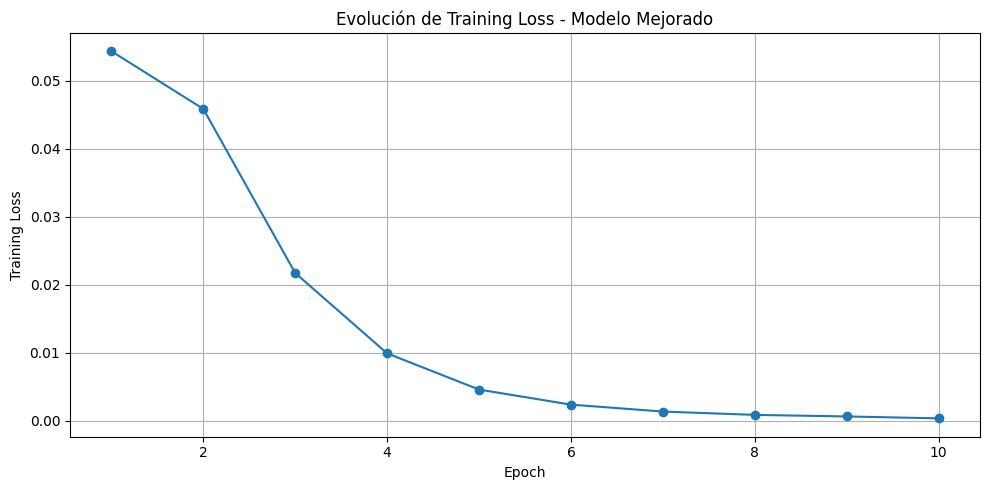

Gráfica guardada en: C:\lara\resultados\03_mejora_modelo\grafica_training_loss_modelo_mejorado.png


In [35]:
# GRÁFICA DE TRAINING LOSS

plt.figure(figsize=(10, 5))

plt.plot(
    df_train_logs["epoch"],
    df_train_logs["loss"],
    marker="o"
)

plt.title("Evolución de Training Loss - Modelo Mejorado")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.tight_layout()

ruta_grafica_training_loss = os.path.join(
    RESULTS_DIR,
    "grafica_training_loss_modelo_mejorado.png"
)

plt.savefig(ruta_grafica_training_loss, dpi=300)
plt.show()

print("Gráfica guardada en:", ruta_grafica_training_loss)

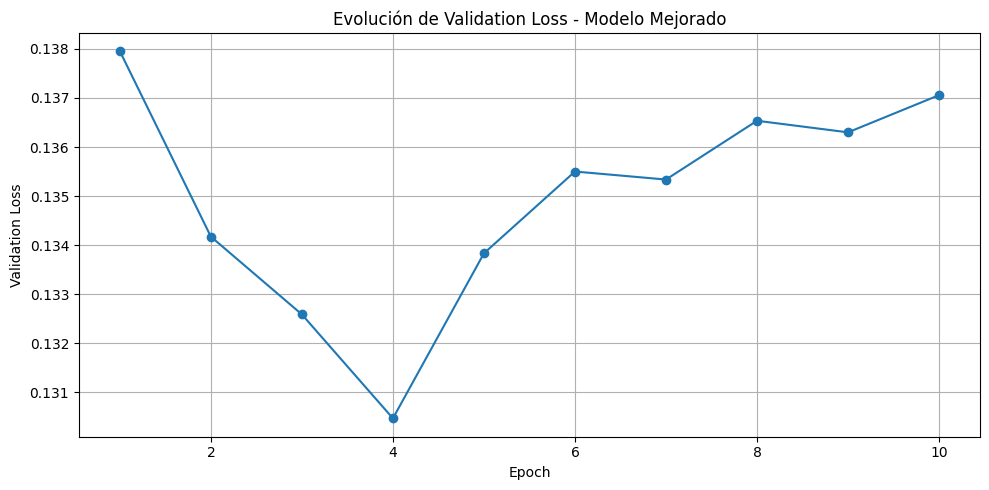

Gráfica guardada en: C:\lara\resultados\03_mejora_modelo\grafica_validation_loss_modelo_mejorado.png


In [40]:
# GRÁFICA DE VALIDATION LOSS

plt.figure(figsize=(10, 5))

plt.plot(
    df_eval_logs_validacion["epoch"],
    df_eval_logs_validacion["eval_loss"],
    marker="o"
)

plt.title("Evolución de Validation Loss - Modelo Mejorado")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.tight_layout()

ruta_grafica_validation_loss = os.path.join(
    RESULTS_DIR,
    "grafica_validation_loss_modelo_mejorado.png"
)

plt.savefig(ruta_grafica_validation_loss, dpi=300)
plt.show()

print("Gráfica guardada en:", ruta_grafica_validation_loss)

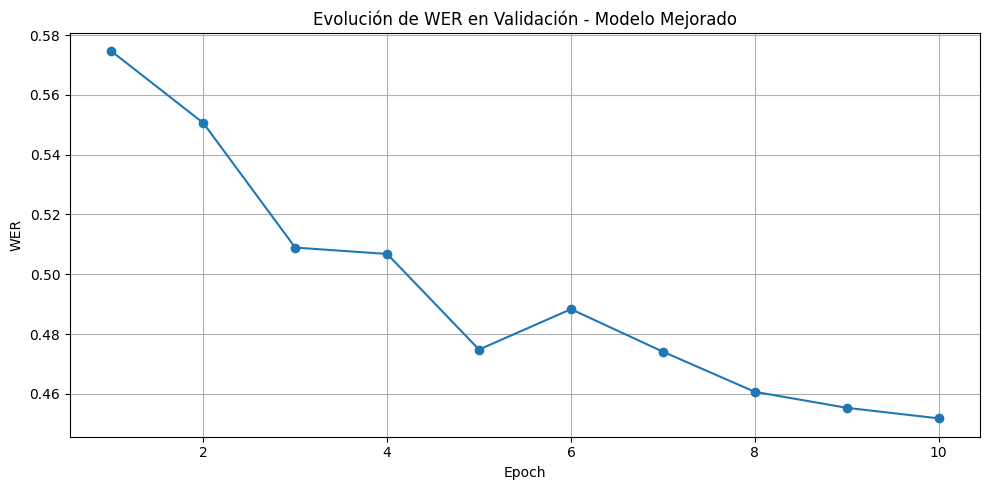

Gráfica guardada en: C:\lara\resultados\03_mejora_modelo\grafica_wer_modelo_mejorado.png


In [41]:
# GRÁFICA DE WER EN VALIDACIÓN

plt.figure(figsize=(10, 5))

plt.plot(
    df_eval_logs_validacion["epoch"],
    df_eval_logs_validacion["eval_wer"],
    marker="o"
)

plt.title("Evolución de WER en Validación - Modelo Mejorado")
plt.xlabel("Epoch")
plt.ylabel("WER")
plt.grid(True)
plt.tight_layout()

ruta_grafica_wer = os.path.join(
    RESULTS_DIR,
    "grafica_wer_modelo_mejorado.png"
)

plt.savefig(ruta_grafica_wer, dpi=300)
plt.show()

print("Gráfica guardada en:", ruta_grafica_wer)

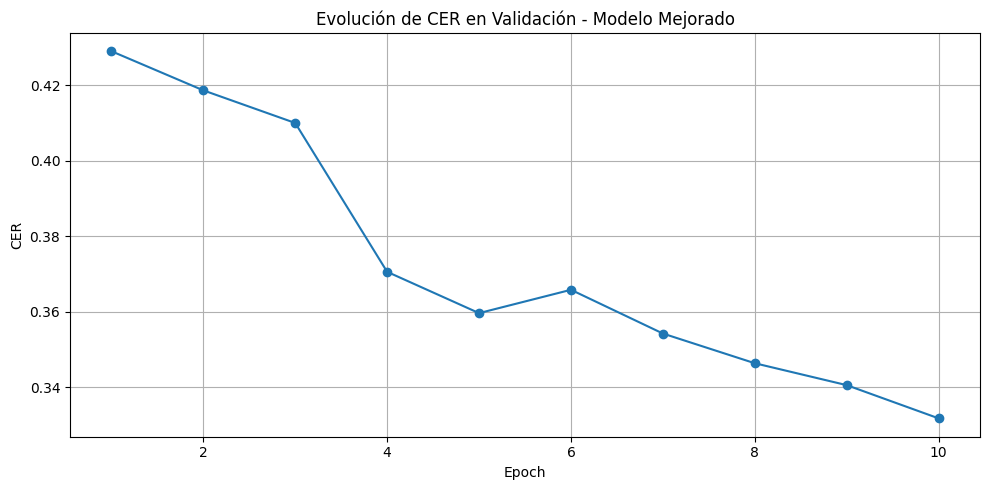

Gráfica guardada en: C:\lara\resultados\03_mejora_modelo\grafica_cer_modelo_mejorado.png


In [42]:
# GRÁFICA DE CER EN VALIDACIÓN

plt.figure(figsize=(10, 5))

plt.plot(
    df_eval_logs_validacion["epoch"],
    df_eval_logs_validacion["eval_cer"],
    marker="o"
)

plt.title("Evolución de CER en Validación - Modelo Mejorado")
plt.xlabel("Epoch")
plt.ylabel("CER")
plt.grid(True)
plt.tight_layout()

ruta_grafica_cer = os.path.join(
    RESULTS_DIR,
    "grafica_cer_modelo_mejorado.png"
)

plt.savefig(ruta_grafica_cer, dpi=300)
plt.show()

print("Gráfica guardada en:", ruta_grafica_cer)

## Comparativa final entre modelo inicial y modelo mejorado

In [43]:
# COMPARATIVA DE MODELOS SOBRE TEST

df_comparativa_modelos = pd.DataFrame([
    {
        "modelo": "Modelo inicial",
        "loss": resultados_test_inicial.get("eval_loss"),
        "wer": resultados_test_inicial.get("eval_wer"),
        "cer": resultados_test_inicial.get("eval_cer")
    },
    {
        "modelo": "Modelo mejorado",
        "loss": resultados_test_mejorado.get("eval_loss"),
        "wer": resultados_test_mejorado.get("eval_wer"),
        "cer": resultados_test_mejorado.get("eval_cer")
    }
])

# Calculamos mejora absoluta y relativa
wer_inicial = df_comparativa_modelos.loc[0, "wer"]
wer_mejorado = df_comparativa_modelos.loc[1, "wer"]

cer_inicial = df_comparativa_modelos.loc[0, "cer"]
cer_mejorado = df_comparativa_modelos.loc[1, "cer"]

mejora_wer_absoluta = wer_inicial - wer_mejorado
mejora_wer_relativa = mejora_wer_absoluta / wer_inicial * 100

mejora_cer_absoluta = cer_inicial - cer_mejorado
mejora_cer_relativa = mejora_cer_absoluta / cer_inicial * 100

print("Comparativa de modelos sobre TEST")
print("----------------------------------------")
display(df_comparativa_modelos)

print("Mejora obtenida")
print("----------------------------------------")
print(f"Mejora absoluta WER: {mejora_wer_absoluta:.6f}")
print(f"Mejora relativa WER: {mejora_wer_relativa:.2f}%")
print(f"Mejora absoluta CER: {mejora_cer_absoluta:.6f}")
print(f"Mejora relativa CER: {mejora_cer_relativa:.2f}%")

# Guardamos la comparativa en CSV
COMPARISON_FILE = os.path.join(
    RESULTS_DIR,
    "comparativa_modelo_inicial_vs_mejorado.csv"
)

df_comparativa_modelos.to_csv(
    COMPARISON_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("----------------------------------------")
print("Comparativa guardada en:", COMPARISON_FILE)

Comparativa de modelos sobre TEST
----------------------------------------


,modelo,loss,wer,cer
0,Modelo inicial,0.132329,0.575575,0.425761
1,Modelo mejorado,0.138303,0.483768,0.356367


Mejora obtenida
----------------------------------------
Mejora absoluta WER: 0.091807
Mejora relativa WER: 15.95%
Mejora absoluta CER: 0.069394
Mejora relativa CER: 16.30%
----------------------------------------
Comparativa guardada en: C:\lara\resultados\03_mejora_modelo\comparativa_modelo_inicial_vs_mejorado.csv


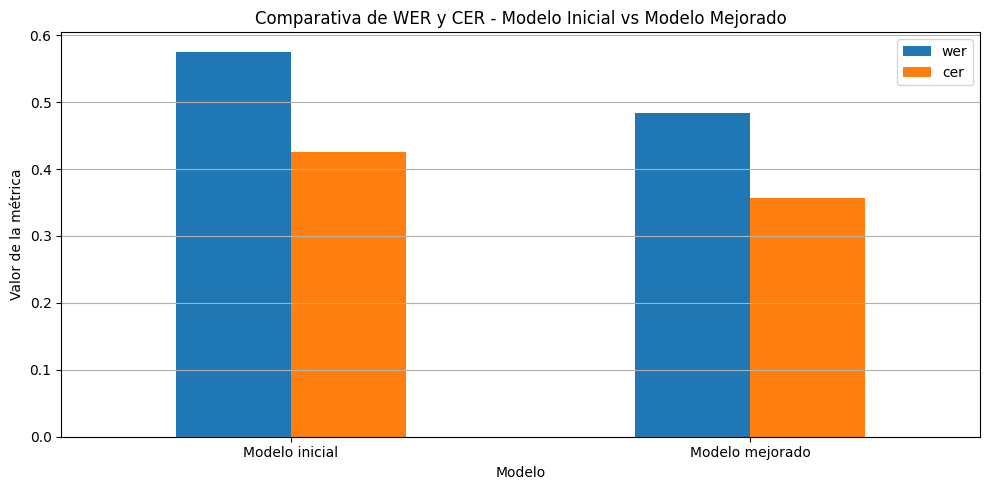

Gráfica guardada en: C:\lara\resultados\03_mejora_modelo\grafica_comparativa_wer_cer_modelos.png


In [44]:
# GRÁFICA COMPARATIVA DE WER Y CER

# Preparamos los datos para graficar solo las métricas principales
df_comparativa_plot = df_comparativa_modelos.set_index("modelo")[["wer", "cer"]]

ax = df_comparativa_plot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)

plt.title("Comparativa de WER y CER - Modelo Inicial vs Modelo Mejorado")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.grid(axis="y")
plt.tight_layout()

ruta_grafica_comparativa = os.path.join(
    RESULTS_DIR,
    "grafica_comparativa_wer_cer_modelos.png"
)

plt.savefig(ruta_grafica_comparativa, dpi=300)
plt.show()

print("Gráfica guardada en:", ruta_grafica_comparativa)

#### Conclusión de la comparativa

El entrenamiento de mejora ha reducido tanto el WER como el CER respecto al modelo inicial.

El WER ha pasado de aproximadamente `0.5756` a `0.4838`, lo que supone una mejora relativa cercana al `15.95%`.

El CER ha pasado de aproximadamente `0.4258` a `0.3564`, con una mejora relativa cercana al `16.30%`.

Esto indica que continuar el fine-tuning del modelo `whisper-base` con un `learning_rate` más bajo, más epochs, acumulación de gradiente y warmup ha sido efectivo.


## Prueba manual del modelo mejorado con muestras aleatorias

In [45]:
# PRUEBA MANUAL DEL MODELO MEJORADO CON MUESTRAS ALEATORIAS

# Número de muestras aleatorias que queremos revisar
NUM_MUESTRAS = 10

# Seleccionamos índices aleatorios del conjunto de test
indices_muestra = random.sample(
    range(len(dataset_splits["test"])),
    NUM_MUESTRAS
)

resultados_muestras = []

# Ponemos el modelo en modo evaluación
model.eval()

for indice_test in indices_muestra:
    muestra = dataset_splits["test"][indice_test]

    # Preparamos las características de audio para el modelo
    input_features = torch.tensor(
        muestra["input_features"],
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    # Generamos la predicción
    with torch.no_grad():
        pred_ids = model.generate(
            input_features,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=NUM_BEAMS
        )

    # Decodificamos la predicción
    texto_predicho = processor.tokenizer.decode(
        pred_ids[0],
        skip_special_tokens=True
    )

    # Decodificamos el texto real
    labels = np.array(muestra["labels"])
    labels[labels == -100] = processor.tokenizer.pad_token_id

    texto_real = processor.tokenizer.decode(
        labels,
        skip_special_tokens=True
    )

    # Calculamos métricas para esta muestra concreta
    wer_muestra = wer_metric.compute(
        predictions=[texto_predicho],
        references=[texto_real]
    )

    cer_muestra = cer_metric.compute(
        predictions=[texto_predicho],
        references=[texto_real]
    )

    resultados_muestras.append({
        "indice_test": indice_test,
        "texto_real": texto_real,
        "texto_predicho": texto_predicho,
        "wer": wer_muestra,
        "cer": cer_muestra
    })

# Creamos DataFrame con los resultados
df_muestras_modelo_mejorado = pd.DataFrame(resultados_muestras)

print("Muestras aleatorias generadas correctamente")
print("----------------------------------------")
display(df_muestras_modelo_mejorado)

[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Muestras aleatorias generadas correctamente
----------------------------------------


,indice_test,texto_real,texto_predicho,wer,cer
0,5238,EL PROFETA DIJO SU PROFECÍA.,EL PROFETA DIJO SU PROFETA.,0.200,0.071429
1,912,ROMÁN SIEMPRE VA A COMER A LA SUREÑA.,ROMÁN SIEMPRE TIENE UNA COMERCA UN SUREÑO.,0.750,0.297297
2,204,DESDE EL MIRADOR SE VE LA ORILLA DEL MAR.,DESDE EL MIRADOR SE VE LA ORILLA DEL MAR.,0.000,0.000000
3,6074,NURIA NADA MUCHO,NURIA NADA MUCHO,0.000,0.000000
4,2253,ME GUSTA EL MELÓN MADURO.,ME GUSTA EL MELÓN MADURO.,0.000,0.000000
5,2006,¿QUIERES SANDÍA O HELADO?,¿TIENES MIEDO A LAS ARAÑAS?,1.250,0.680000
6,1828,ESTAMOS DE JANGUEO EN HALLOWEEN.,ESTAMOS DE JANGUEO EN HALLOWEEN.,0.000,0.000000
7,1143,IVAN ESTÁ EN ITALIA,LLEVANTÉ EN SEJER DE VENTANACIÓN.,1.250,1.157895
8,6033,EL DOMINGO VEREMOS A DIANA.,EL DOMINGO VEREMOS A DIANA.,0.000,0.000000
9,839,LA JIRAFA Y EL JABALÍ NO TIENEN JOROBA.,LA VIDA ESTABA LLENA DE ARAÑAS,0.875,0.589744


In [53]:
# CARGA DEL DATASET ORIGINAL SIN DECODIFICAR AUDIO

dataset_original = load_from_disk(INPUT_DATASET)

# Evitamos que Hugging Face intente decodificar el audio automáticamente
dataset_original = dataset_original.cast_column(
    "audio",
    Audio(decode=False)
)

print("Dataset original cargado sin decodificar audio")
print("----------------------------------------")
print(dataset_original)
print("Registros dataset original:", len(dataset_original))

Dataset original cargado sin decodificar audio
----------------------------------------
Dataset({
    features: ['audio', 'texto'],
    num_rows: 40842
})
Registros dataset original: 40842


In [54]:
# VISUALIZACIÓN DETALLADA DE MUESTRAS ALEATORIAS CON AUDIO

for _, fila in df_muestras_modelo_mejorado.iterrows():
    indice_test = int(fila["indice_test"])
    indice_original = int(fila["indice_original"])

    registro_original = dataset_original[indice_original]

    # Recuperamos la información del audio sin decodificar
    audio_info = registro_original["audio"]

    if isinstance(audio_info, dict):
        ruta_audio = audio_info.get("path")
    else:
        ruta_audio = audio_info

    # Si la ruta no es absoluta, la completamos usando la carpeta de audios
    if not os.path.isabs(ruta_audio):
        ruta_audio = os.path.join(AUDIOS_CONVERTED_PATH, ruta_audio)

    print("Índice test:", indice_test)
    print("Índice original:", indice_original)
    print("Ruta audio:", ruta_audio)
    print("Texto real:     ", fila["texto_real"])
    print("Texto predicho: ", fila["texto_predicho"])
    print("WER:", round(fila["wer"], 4), "| CER:", round(fila["cer"], 4))

    # Cargamos el audio con librosa para evitar problemas de decodificación de datasets
    try:
        audio_array, sampling_rate = librosa.load(
            ruta_audio,
            sr=SAMPLING_RATE
        )

        display(IPythonAudio(audio_array, rate=sampling_rate))

    except Exception as error:
        print("No se pudo reproducir el audio:", error)

    print("----------------------------------------")

Índice test: 5238
Índice original: 25012
Ruta audio: C:\lara\audios-230426\audios-s3\6784f4cf95eb7d469152bcba_1740393365.ogg
Texto real:      EL PROFETA DIJO SU PROFECÍA.
Texto predicho:  EL PROFETA DIJO SU PROFETA.
WER: 0.2 | CER: 0.0714


----------------------------------------
Índice test: 912
Índice original: 28552
Ruta audio: C:\lara\audios-230426\audios-s3\6628187f1ef22d020bf25232_1743402684.wav
Texto real:      ROMÁN SIEMPRE VA A COMER A LA SUREÑA.
Texto predicho:  ROMÁN SIEMPRE TIENE UNA COMERCA UN SUREÑO.
WER: 0.75 | CER: 0.2973


C:\Users\abelg\AppData\Local\Temp\ipykernel_22520\2170640189.py:30: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_array, sampling_rate = librosa.load(


----------------------------------------
Índice test: 204
Índice original: 33782
Ruta audio: C:\lara\audios-230426\audios-s3\662819171ef22d020bf25236_1750314458.wav
Texto real:      DESDE EL MIRADOR SE VE LA ORILLA DEL MAR.
Texto predicho:  DESDE EL MIRADOR SE VE LA ORILLA DEL MAR.
WER: 0.0 | CER: 0.0


----------------------------------------
Índice test: 6074
Índice original: 38363
Ruta audio: C:\lara\audios-230426\audios-s3\67990a2e95cbee60f5ec1f54_1771955262.wav
Texto real:      NURIA NADA MUCHO
Texto predicho:  NURIA NADA MUCHO
WER: 0.0 | CER: 0.0


...

----------------------------------------
Índice test: 1828
Índice original: 32544
Ruta audio: C:\lara\audios-230426\audios-s3\662819171ef22d020bf25236_1747895851.wav
Texto real:      ESTAMOS DE JANGUEO EN HALLOWEEN.
Texto predicho:  ESTAMOS DE JANGUEO EN HALLOWEEN.
WER: 0.0 | CER: 0.0


----------------------------------------
Índice test: 1143
Índice original: 38026
Ruta audio: C:\lara\audios-230426\audios-s3\662a39c6d3f7e3d0e780eedd_1771933178.wav
Texto real:      IVAN ESTÁ EN ITALIA
Texto predicho:  LLEVANTÉ EN SEJER DE VENTANACIÓN.
WER: 1.25 | CER: 1.1579


----------------------------------------
Índice test: 6033
Índice original: 9850
Ruta audio: C:\lara\audios-230426\audios-s3\662819171ef22d020bf25236_1717653920.wav
Texto real:      EL DOMINGO VEREMOS A DIANA.
Texto predicho:  EL DOMINGO VEREMOS A DIANA.
WER: 0.0 | CER: 0.0


----------------------------------------
Índice test: 839
Índice original: 20001
Ruta audio: C:\lara\audios-230426\audios-s3\662819171ef22d020bf25236_1737014098.wav
Texto real:      LA JIRAFA Y EL JABALÍ NO TIENEN JOROBA.
Texto predicho:  LA VIDA ESTABA LLENA DE ARAÑAS
WER: 0.875 | CER: 0.5897


----------------------------------------
